In [33]:
import numpy as np
import pandas as pd
import torch
from PIL import Image

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

def _to_pil(img, image_processor=None):
    """Convert PIL / numpy / processor-normalized tensor -> PIL.Image (uint8)."""
    if isinstance(img, Image.Image):
        return img

    if isinstance(img, torch.Tensor):
        # Accept (B,3,H,W) or (3,H,W). If normalized, unnormalize via processor.
        if img.ndim == 4:
            img = img[0]
        assert img.ndim == 3 and img.shape[0] in (1,3), "Expect (C,H,W) tensor."
        x = img.clone()

        # If in [-~3, ~3] range (typical normalized), try unnormalize
        if image_processor is not None and (x.max() > 1.5 or x.min() < -0.5):
            mean = torch.tensor(
                getattr(image_processor, "image_mean", [0.5, 0.5, 0.5]),
                dtype=x.dtype, device=x.device
            )[:, None, None]
            std = torch.tensor(
                getattr(image_processor, "image_std", [0.5, 0.5, 0.5]),
                dtype=x.dtype, device=x.device
            )[:, None, None]
            x = x * std + mean

        # Move to CPU, [0,1], CHW->HWC uint8
        x = x.clamp(0,1).permute(1,2,0).detach().cpu().numpy()
        arr = (x * 255).round().astype(np.uint8)
        return Image.fromarray(arr)

    if isinstance(img, np.ndarray):
        if img.dtype != np.uint8:
            arr = np.clip(img, 0, 1)
            arr = (arr * 255).round().astype(np.uint8)
        else:
            arr = img
        if arr.ndim == 3 and arr.shape[2] == 3:
            return Image.fromarray(arr)
        raise ValueError("NumPy image must be HxWx3.")
    raise TypeError("Unsupported image type. Use PIL.Image, torch.Tensor, or np.ndarray.")

def _coerce_boxes(boxes):
    norm = []
    for b in boxes:
        if isinstance(b, dict):
            xmin, ymin, xmax, ymax = b["xmin"], b["ymin"], b["xmax"], b["ymax"]
        else:
            xmin, ymin, xmax, ymax = b  # (xmin,ymin,xmax,ymax)
        norm.append((float(xmin), float(ymin), float(xmax), float(ymax)))
    return norm


def plot_patch_mask_on_image(
    image_or_tensor,
    patch_mask,                      # 1D (576,) or 2D (24,24) array of 0/1
    image_processor=None,
    grid_hw=(24, 24),                # (rows, cols)
    color="cyan",                    # fill color for 1-patches
    alpha=0.25,                      # transparency for fills
    draw_grid=False,                 # optional thin grid lines
    grid_linewidth=0.3,
    grid_linecolor="white"
):
    """
    Overlay a 24x24 (default) binary mask on a 336x336 image as light-colored patches.

    Args:
        image_or_tensor: PIL.Image | torch.Tensor (C,H,W or B,C,H,W) | np.ndarray (H,W,3)
        patch_mask: np.ndarray or list with shape (576,) or (24,24) containing 0/1
        image_processor: optional processor for unnormalizing tensors (same as _to_pil)
        grid_hw: (rows, cols) of the patch grid; default (24,24)
        color: facecolor for active (1) patches
        alpha: transparency for fills (0 transparent, 1 opaque)
        draw_grid: draw thin grid lines for reference
        grid_linewidth: linewidth for grid lines
        grid_linecolor: color for grid lines
    Returns:
        (fig, ax)
    """
    pil = _to_pil(image_or_tensor, image_processor=image_processor)
    W, H = pil.size
    rows, cols = grid_hw

    # Compute patch size from image size & grid (works for 336x336 with 24x24 -> 14x14)
    patch_w = W // cols
    patch_h = H // rows

    # Coerce mask to (rows, cols)
    pm = np.asarray(patch_mask)
    if pm.ndim == 1:
        assert pm.size == rows * cols, f"1D patch_mask must have {rows*cols} elements."
        pm = pm.reshape(rows, cols)
    else:
        assert pm.shape == (rows, cols), f"patch_mask must be shape {(rows, cols)}"

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(pil)
    ax.axis("off")

    # Draw filled rectangles where mask == 1
    # (row, col) -> rectangle at (col*patch_w, row*patch_h)
    act_positions = np.argwhere(pm > 0)
    for r, c in act_positions:
        left = int(c * patch_w)
        top  = int(r * patch_h)
        rect = Rectangle(
            (left, top),
            patch_w,
            patch_h,
            linewidth=0,
            edgecolor=None,
            facecolor=color,
            alpha=alpha
        )
        ax.add_patch(rect)

    # Optional thin grid overlay
    if draw_grid:
        # vertical lines
        for c in range(cols + 1):
            x = c * patch_w
            ax.plot([x, x], [0, H], linewidth=grid_linewidth, color=grid_linecolor, alpha=0.6)
        # horizontal lines
        for r in range(rows + 1):
            y = r * patch_h
            ax.plot([0, W], [y, y], linewidth=grid_linewidth, color=grid_linecolor, alpha=0.6)

    plt.tight_layout()
    return fig, ax

In [ ]:
from transformers import CLIPVisionModel, CLIPImageProcessor, CLIPVisionConfig
image_processor = CLIPImageProcessor.from_pretrained('openai/clip-vit-large-patch14-336')

In [6]:
path = "/Data2/Arun-UAV/NLP/vision_halu/total_flow_testing_results/chair/combined_stage_label_with_evidence_and_mlp_09_11_2025.pkl"

In [7]:
res_data = pd.read_pickle(path)

In [59]:
all_halu_words = []
all_image_paths = []
all_answers = []
for inx, row in res_data.iterrows():
    res = row["labels_with_evidence"]
    seq = row["answer"]
    all_image_paths.append(row["image_path"])
    all_answers.append(seq)
    hal_words = []
    for i in res:
        viz_evi = (torch.tensor(i["evidence"]) >= 0.5).int().sum().item()
        prob = i["label"]
        if viz_evi >= 10:
            hal_words.append(i["word"])
    all_halu_words.append(hal_words)

In [144]:
i = 90

In [145]:
print(all_halu_words[i])
print(all_answers[i])

['man', 'sitting', 'dining', 'table,', 'smiling', 'enjoying', 'meal.', 'holding', 'large', 'pizza', 'placed', 'front', 'pizza', 'sliced', 'pepperoni', 'pizza.', 'table', 'two', 'other', 'people', 'left', 'right', 'side', 'table.', 'dining', 'table', 'space', 'man', 'sitting', 'center', 'scene.']
The image features a man sitting at a dining table, smiling and enjoying a meal. He is holding a fork and knife, ready to dig into a large pizza placed in front of him. The pizza is sliced and appears to be a pepperoni pizza. 

The table is set with various items, including a wine glass, a cup, and a bowl. There are also two other people in the scene, one on the left side and another on the right side of the table. The dining table occupies most of the space in the image, with the man sitting in the center of the scene.


In [140]:
df = pd.DataFrame(res_data.iloc[i]["labels_with_evidence"])
target_viz_evi = df[df["word"] == "rusty"]["evidence"].iloc[0]

In [141]:
viz_evi_mask = (torch.tensor(target_viz_evi) >= 0.6).int()

In [142]:
image_path = all_image_paths[i]
image = Image.open(image_path).convert("RGB")
image_tensor = image_processor([image], return_tensors="pt")["pixel_values"]

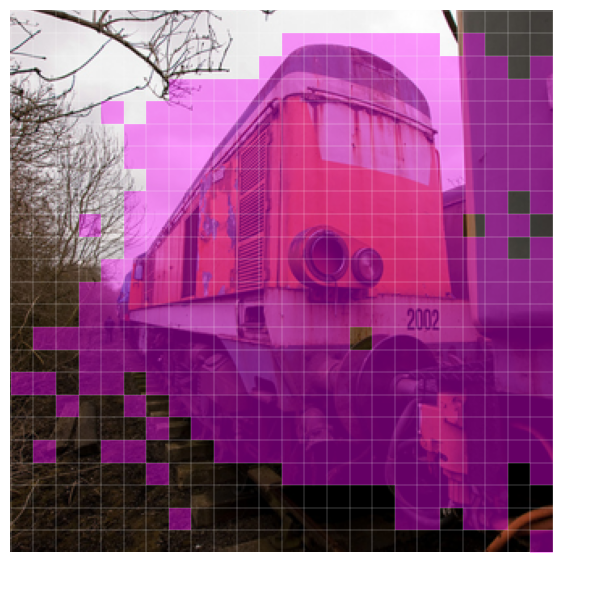

In [143]:
# image_tensor: (3,336,336) or (1,3,336,336) normalized by LLaVA processor
# patch_mask_1d: np.array shape (576,) with 0/1
fig, ax = plot_patch_mask_on_image(
    image_tensor,
    viz_evi_mask.numpy(),
    image_processor=image_processor,
    color="magenta",
    alpha=0.4,
    draw_grid=True
)

In [ ]:
res_data = pd.read_pickle(path)

all_seqs = []
ids = []
for inx, row in res_data.iterrows():
    res = row["labels_with_evidence"]
    seq = row["answer"]
    hal_words = []
    for i in res:
        viz_evi = (torch.tensor(i["evidence"]) >= 0.5).int().sum().item()
        prob = i["label"]
        if prob <= 0.7:
            hal_words.append(i["word"])
        elif viz_evi <= 3 and prob <= 0.9:
            hal_words.append(i["word"])
    for hw in hal_words:
            seq = seq.replace(hw.strip().strip("."), "")
    all_seqs.append(seq)
    ids.append(row["question_id"])
    
res_data["answer"] = all_seqs
res_data.to_json("/Data2/Arun-UAV/NLP/vision_halu/total_flow_testing_results/chair/chair_rule_base_mitigation_res.jsonl", lines=True, orient="records")

In [19]:
import plotly.express as px
import pandas as pd

# Data
data = {
    "Method": ["Regular", "DOLA", "OPERA", "VCD", "AGLA", "D-J-Fix(Ours)"],
    "Existence": [175.67, 175, 180.67, 184.66, 195, 195],
    "Count": [124.67, 108.33, 133.33, 138.33, 153.89, 163.34],
    "Position": [114, 90, 123.33, 128.67, 129.44, 128.34],
    "Color": [151, 138.33, 155, 153, 161.67, 160],
    # "Total": [565.34, 511.66, 592.33, 604.66, 640, 646.68]
}

df = pd.DataFrame(data)
df_long = df.melt(id_vars='Method', var_name='Category', value_name='Score')

# Professional color palette
custom_colors = {
    "Regular": "#5DA5DA",       # blue
    "DOLA": "#FAA43A",          # orange
    "OPERA": "#60BD68",         # green
    "VCD": "#F17CB0",           # pink
    "AGLA": "#B2912F",          # gold-brown
    "D-J-Fix(Ours)": "#B276B2"  # purple
}

# Create bar plot
fig = px.bar(
    df_long,
    x="Category",
    y="Score",
    color="Method",
    barmode="group",
    color_discrete_map=custom_colors,
    text_auto=False  # no numbers on bars
)

# Layout adjustments
fig.update_layout(
    width=570,
    height=380,
    bargap=0.1,        # ↓ reduced spacing between groups (default ~0.15)
    bargroupgap=0.1,   # ↓ reduced spacing within each group
    xaxis_title=None,
    yaxis_title=None,
    xaxis=dict(
        tickfont=dict(size=14, style='italic'),
        showgrid=True,
        gridcolor='rgba(200,200,200,0.3)',  # subtle vertical grid lines
        zeroline=False
    ),
    yaxis=dict(
        range=[0, 200],
        tickfont=dict(size=12),
        showgrid=True,
        gridcolor='rgba(230,230,230,0.4)',
        zeroline=False
    ),
    legend=dict(
        title=None,
        orientation='h',
        yanchor='bottom',
        y=1.05,
        xanchor='center',
        x=0.5,
        font=dict(size=12)
    ),
    plot_bgcolor='white'
)

fig.show()

In [2]:
! pip install nbformat>=4.2.0